In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
players = pd.read_csv('Players.csv')
players.head()

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
0,0,Curly Armstrong,180.0,77.0,Indiana University,1918.0,NaN,NaN
1,1,Cliff Barker,188.0,83.0,University of Kentucky,1921.0,Yorktown,Indiana
2,2,Leo Barnhorst,193.0,86.0,University of Notre Dame,1924.0,NaN,NaN
3,3,Ed Bartels,196.0,88.0,North Carolina State University,1925.0,NaN,NaN
4,4,Ralph Beard,178.0,79.0,University of Kentucky,1927.0,Hardinsburg,Kentucky


In [5]:
players_data = pd.read_csv('player_data.csv')
players_data.head()

,name,year_start,year_end,position,height,weight,birth_date,college
0,Alaa Abdelnaby,1991,1995,F-C,6-10,240.0,"June 24, 1968",Duke University
1,Zaid Abdul-Aziz,1969,1978,C-F,6-9,235.0,"April 7, 1946",Iowa State University
2,Kareem Abdul-Jabbar,1970,1989,C,7-2,225.0,"April 16, 1947","University of California, Los Angeles"
3,Mahmoud Abdul-Rauf,1991,2001,G,6-1,162.0,"March 9, 1969",Louisiana State University
4,Tariq Abdul-Wahad,1998,2003,F,6-6,223.0,"November 3, 1974",San Jose State University


In [6]:
seasons_data = pd.read_csv('Seasons_Stats.csv')
seasons_data.head()

,Unnamed: 0,Year,Player,Pos,Age,Tm,G,GS,MP,PER,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,0,1950.0,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,NaN,...,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1,1950.0,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,NaN,...,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,2,1950.0,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,NaN,...,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0
3,3,1950.0,Ed Bartels,F,24.0,TOT,15.0,NaN,NaN,NaN,...,0.559,NaN,NaN,NaN,20.0,NaN,NaN,NaN,29.0,63.0
4,4,1950.0,Ed Bartels,F,24.0,DNN,13.0,NaN,NaN,NaN,...,0.548,NaN,NaN,NaN,20.0,NaN,NaN,NaN,27.0,59.0


**Хочу перевірити, як вік початку кар'єри впливає на тривалість кар'єри. Для цього я створю 2 нові фічі для датасету player_data:**
1. Рік вік початку кар'єри:

In [28]:
temp_year = pd.to_datetime(players_data['birth_date']).dt.year
players_data['start_age'] = players_data['year_start'] - temp_year
players_data['start_age']

0       23.0
1       23.0
2       23.0
3       22.0
4       24.0
        ... 
4545    21.0
4546    30.0
4547    23.0
4548    20.0
4549    30.0
Name: start_age, Length: 4550, dtype: float64

2. Тривалість кар'єри:

In [29]:
players_data['career_length'] = players_data['year_end'] - players_data['year_start']
players_data['career_length']

0        4
1        9
2       19
3       10
4        5
        ..
4545     0
4546     0
4547     0
4548     1
4549     0
Name: career_length, Length: 4550, dtype: int64


Тепер можемо вивести діаграмму

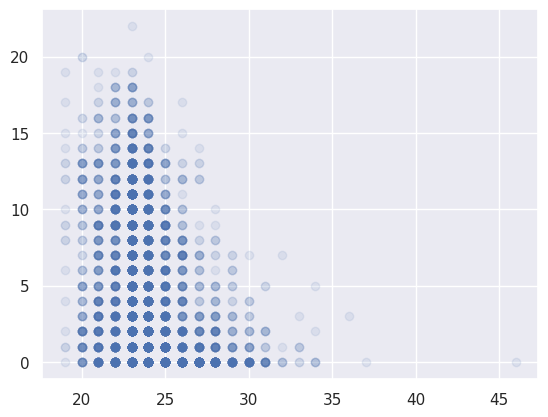

In [45]:
plt.scatter(players_data['start_age'], players_data['career_length'], alpha=0.1)


Ми бачимо, що в середньому граці, котрі почали кар'єру десь у віці 23-25 років, грають найдовше, аніж інші 

**Тепер я хочу подивитись гістограми про кожну з колонок**

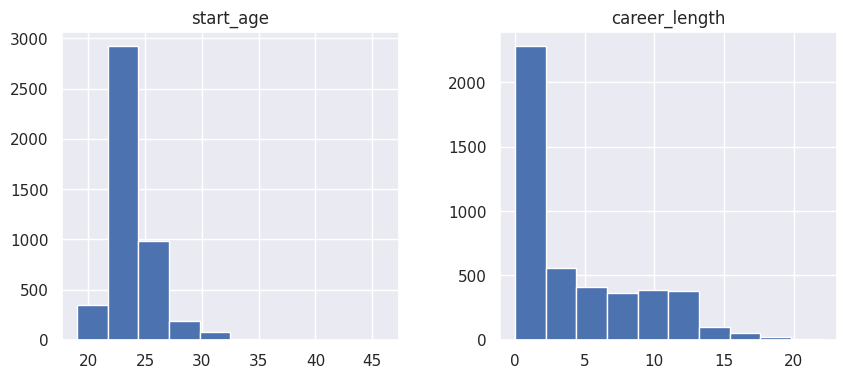

In [48]:
features = ["start_age", "career_length"]
players_data[features].hist(figsize=(10, 4));

Звідси ми бачимо, що кількість гравців, котрі почали свою кар'єру в діапазоні з 23 до 25 років, набагато більше аніж в інші діапазони, тому і логічно, що їх за статистикою вони грають довше. 

**Я хочу подивитися на статистику кількості участників команд**

<Axes: xlabel='Tm'>

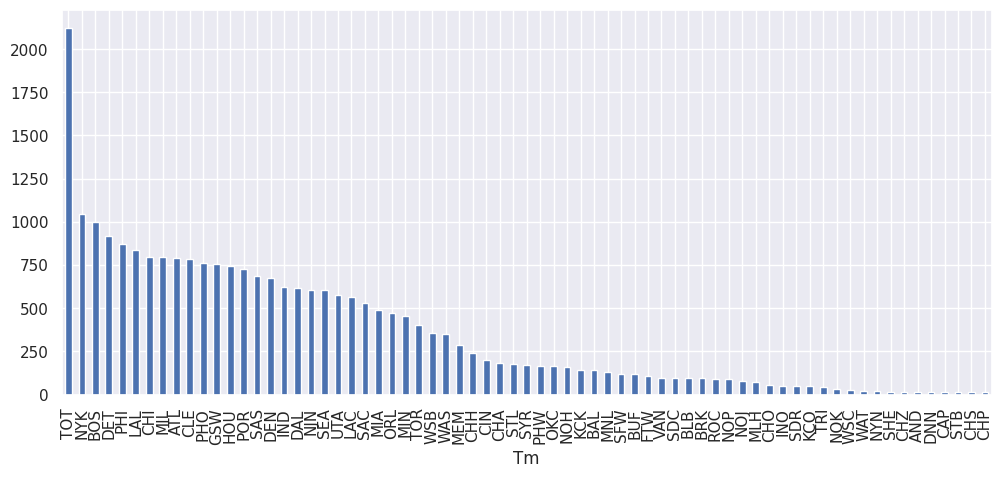

In [65]:
seasons_data['Tm'].value_counts().plot(kind='bar', figsize=(12, 5))

За гістограмою бачимо, що кількість гравців в TOT підозріло відрізняється, подивившись в інтернеті, я дізнався що ТОТ, в статистиці баскетболу, ставлять тим, хто с сезон грав за декілька команд, тому для подальших дій я хочу прибрати усі записи про TOT:

<Axes: xlabel='Tm'>

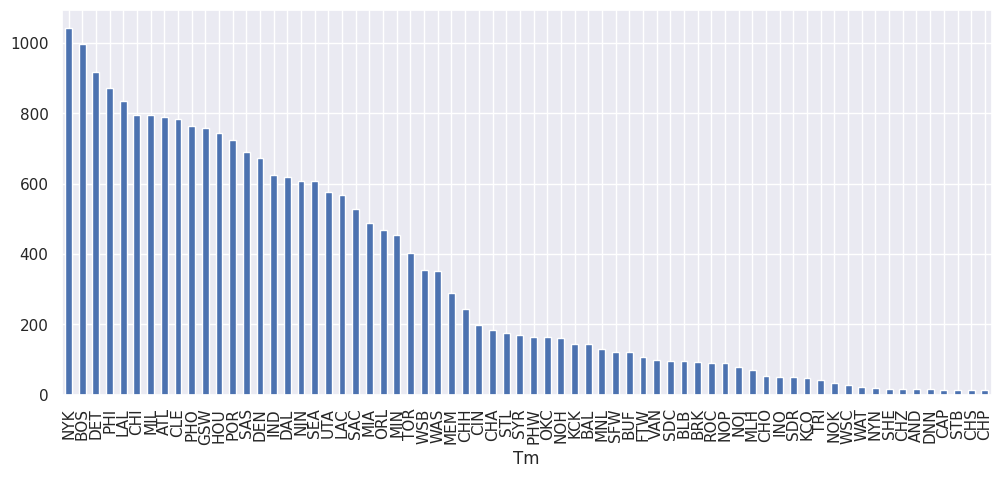

In [76]:
seasons_without_tot = seasons_data[seasons_data['Tm'] != 'TOT']
team_players_count = seasons_without_tot['Tm'].value_counts()
team_players_count.plot(kind='bar', figsize=(12, 5))

Чудово, тепер ми бачимо кількість гравців у кожні команді

**Тепер створю статистику кількості балів на гравця у кожній команді**

<Axes: xlabel='Tm'>

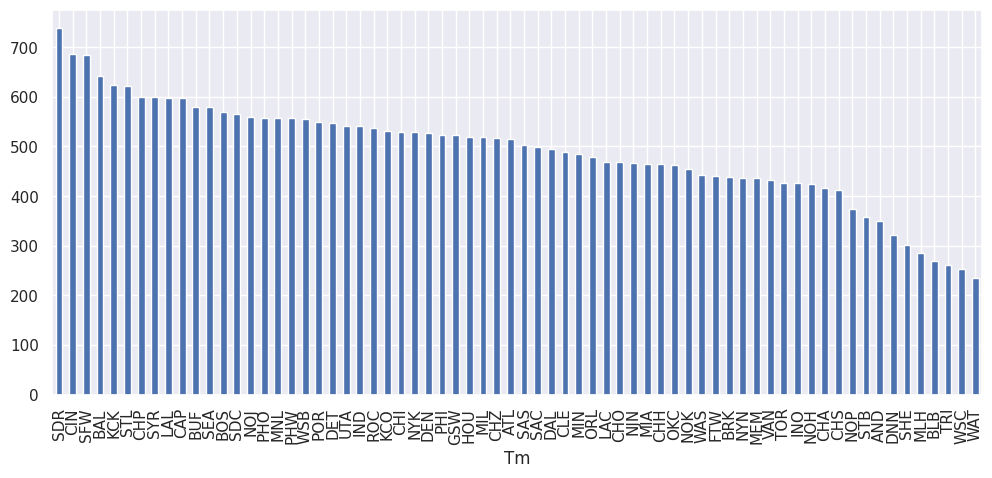

In [85]:
team_groups = seasons_without_tot.groupby('Tm')['PTS'].describe()['mean'].sort_values(ascending=False)
team_groups.plot(kind='bar', figsize=(12, 5))

Ми бачимо, що незважаючи на різну кількість гравців у командах, більшість не колосальну різницю поінтів на гравця

**В інтернеті я знайшов, що золотий вік гравця це 24-29 років, тому додамо фічу, котра за це відповідає**

/tmp/ipykernel_4043/3167382044.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seasons_without_tot['is_prime'] = seasons_without_tot['Age'].apply(lambda x: 27 <= x <= 30)


<Axes: xlabel='is_prime'>

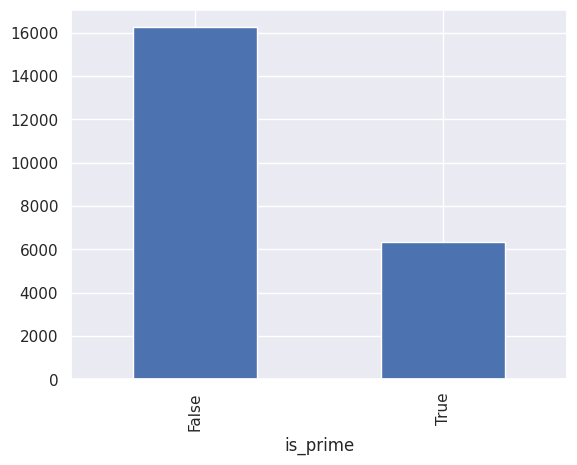

In [92]:
seasons_without_tot['is_prime'] = seasons_without_tot['Age'].apply(lambda x: 27 <= x <= 30)
seasons_without_tot['is_prime'].value_counts().plot(kind='bar')

Більшість гравців грали не золотому віці

**Тепер хочу з'ясувати в яких містах найбільше народилось гравців**

<Axes: xlabel='birth_city'>

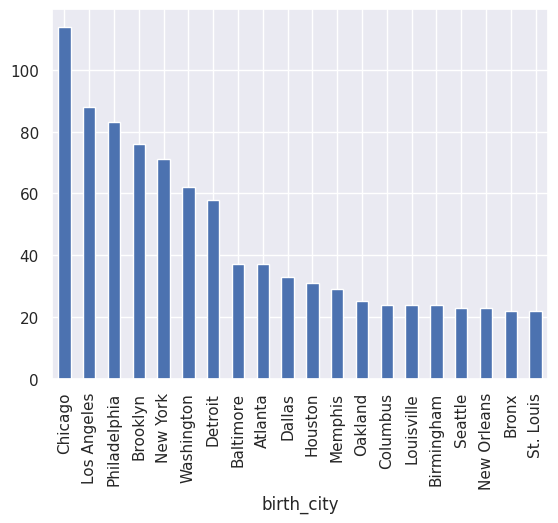

In [104]:
players.groupby('birth_city')['Player'].count().sort_values(ascending=False).head(20).plot(kind='bar')

Взяв найбільші 20, що гістограма була читабельною. Можемо побачити топ міст.

**Додам фічу за народженням в місті, котре входить в топ 10 за кількістю гравців**

In [106]:
top_10_cities = [
    "Chicago",
    "Los Angeles",
    "Philadelphia",
    "Brooklyn",
    "New York",
    "Washington",
    "Detroit",
    "Baltimore",
    "Atlanta",
    "Dallas"
]
players["from_top_10_cities"] = players['birth_city'].apply(lambda x: x in top_10_cities)
players["from_top_10_cities"].head(10)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7     True
8    False
9    False
Name: from_top_10_cities, dtype: bool

Подивимось гістограму

<Axes: xlabel='from_top_10_cities'>

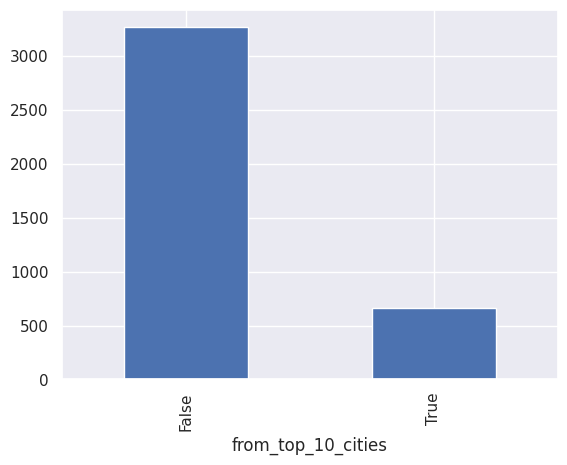

In [107]:
players['from_top_10_cities'].value_counts().plot(kind='bar')

Кількість гравців не з топ 10 міст велика, але в співвідношенні не дуже могла бути і більша

**Додам фічу вижче або нижче медіани зросту**

<Axes: xlabel='is_above_mid_median'>

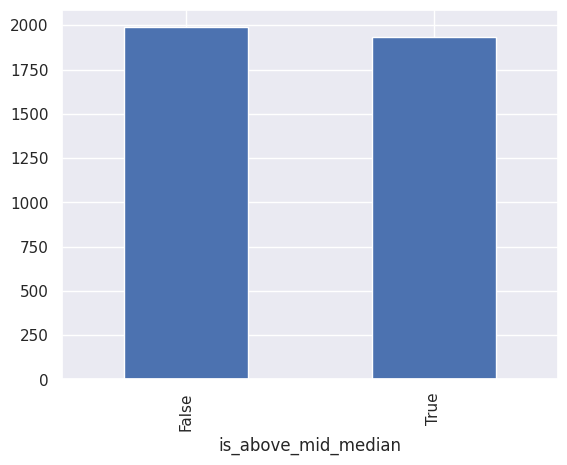

In [110]:
players_mid_height = players['height'].median()
players['is_above_mid_median'] = players['height'].apply(lambda x: x > players_mid_height)
players['is_above_mid_median'].value_counts().plot(kind='bar')

Гравців майже однакове співідношення